In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.utils import make_grid

from torch.utils.data import Dataset, DataLoader

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [3]:
IMAGE_SIZE = 64

LATENT_DIM = 100

BATCH_SIZE = 16

EPOCHS = 50

LR = 0.0002

In [4]:
LONG_HAIR = {
    "madonna": 1,
    "mindy_kaling": 1,

    "ben_afflek": 0,
    "elton_john": 0,
    "jerry_seinfeld": 0
}

In [5]:
class LongHairDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        for celebrity in os.listdir(root_dir):

            celeb_path = os.path.join(
                root_dir,
                celebrity
            )

            if not os.path.isdir(celeb_path):
                continue

            label = LONG_HAIR[celebrity]

            for img in os.listdir(celeb_path):

                if img.lower().endswith(
                    (".jpg",".jpeg",".png")
                ):

                    self.samples.append(
                        (
                            os.path.join(
                                celeb_path,
                                img
                            ),
                            label
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
transform = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

dataset = LongHairDataset(
    "/home/saidul/Desktop/4-2/Deep Learning/data/5_celebrity_faces/train",
    transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Images:", len(dataset))

Images: 93


In [7]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.label_emb = nn.Embedding(
            2,
            50
        )

        self.main = nn.Sequential(

            nn.ConvTranspose2d(
                150,
                512,
                4,
                1,
                0,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512,
                256,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                3,
                4,
                2,
                1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, noise, labels):

        label_embedding = self.label_emb(
            labels
        )

        x = torch.cat(
            [noise, label_embedding],
            dim=1
        )

        x = x.view(
            -1,
            150,
            1,
            1
        )

        return self.main(x)

In [8]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.label_emb = nn.Embedding(
            2,
            64*64
        )

        self.main = nn.Sequential(

            nn.Conv2d(
                4,
                64,
                4,
                2,
                1
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                256,
                512,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                512,
                1,
                4,
                1,
                0
            ),

            nn.Sigmoid()
        )

    def forward(self, images, labels):

        label_map = self.label_emb(
            labels
        )

        label_map = label_map.view(
            -1,
            1,
            64,
            64
        )

        x = torch.cat(
            [images, label_map],
            dim=1
        )

        return self.main(x).view(-1)

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerG = torch.optim.Adam(
    G.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

optimizerD = torch.optim.Adam(
    D.parameters(),
    lr=LR,
    betas=(0.5,0.999)
)

In [12]:
g_losses = []
d_losses = []

for epoch in range(EPOCHS):

    for real_images, labels in tqdm(loader):

        real_images = real_images.to(device)

        labels = labels.to(device)

        batch_size = real_images.size(0)

        real_target = torch.ones(
            batch_size,
            device=device
        )

        fake_target = torch.zeros(
            batch_size,
            device=device
        )

        ################################
        # Train D
        ################################

        optimizerD.zero_grad()

        real_output = D(
            real_images,
            labels
        )

        loss_real = criterion(
            real_output,
            real_target
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = G(
            noise,
            labels
        )

        fake_output = D(
            fake_images.detach(),
            labels
        )

        loss_fake = criterion(
            fake_output,
            fake_target
        )

        lossD = loss_real + loss_fake

        lossD.backward()

        optimizerD.step()

        ################################
        # Train G
        ################################

        optimizerG.zero_grad()

        output = D(
            fake_images,
            labels
        )

        lossG = criterion(
            output,
            real_target
        )

        lossG.backward()

        optimizerG.step()

    g_losses.append(lossG.item())
    d_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D={lossD.item():.4f} "
        f"G={lossG.item():.4f}"
    )

100%|██████████| 6/6 [00:03<00:00,  1.98it/s]


Epoch [1/50] D=1.5221 G=3.9910


100%|██████████| 6/6 [00:03<00:00,  1.72it/s]


Epoch [2/50] D=0.8676 G=7.1206


100%|██████████| 6/6 [00:03<00:00,  1.88it/s]


...

Epoch [48/50] D=1.1003 G=7.6555


100%|██████████| 6/6 [00:03<00:00,  1.73it/s]


Epoch [49/50] D=0.9936 G=4.5438


100%|██████████| 6/6 [00:03<00:00,  1.90it/s]

Epoch [50/50] D=0.3923 G=3.9542


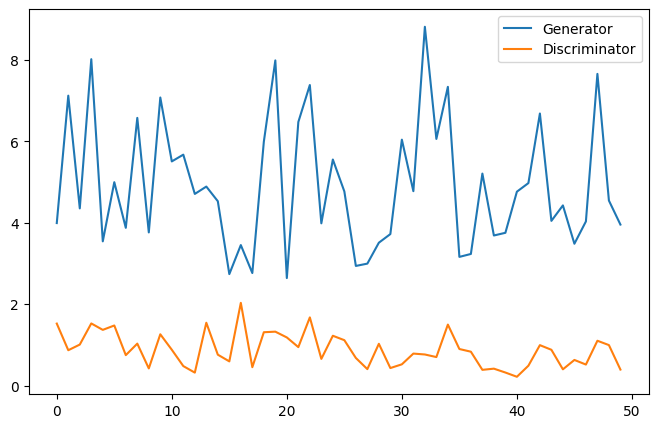

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    g_losses,
    label="Generator"
)

plt.plot(
    d_losses,
    label="Discriminator"
)

plt.legend()

plt.show()

In [14]:
G.eval()

with torch.no_grad():

    labels = torch.ones(
        16,
        dtype=torch.long,
        device=device
    )

    noise = torch.randn(
        16,
        LATENT_DIM,
        device=device
    )

    fake_long = G(
        noise,
        labels
    ).cpu()

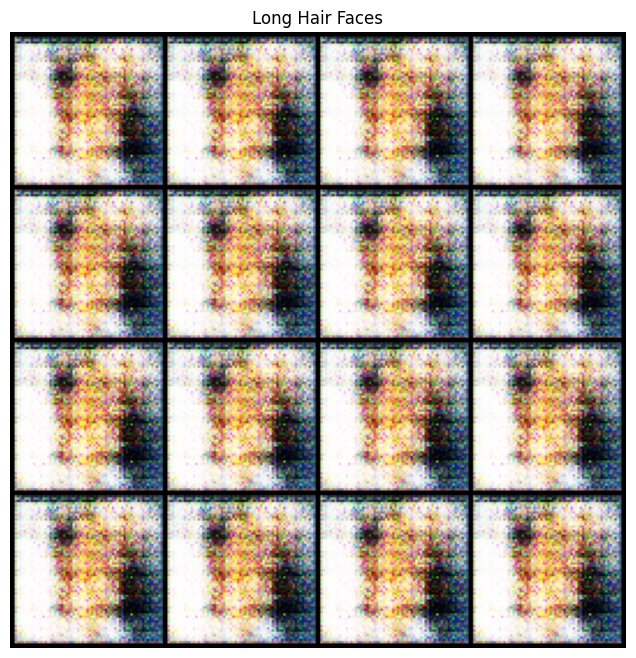

In [15]:
grid = make_grid(
    fake_long,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.transpose(
        grid.numpy(),
        (1,2,0)
    )
)

plt.title("Long Hair Faces")

plt.axis("off")

plt.show()

In [16]:
with torch.no_grad():

    labels = torch.zeros(
        16,
        dtype=torch.long,
        device=device
    )

    noise = torch.randn(
        16,
        LATENT_DIM,
        device=device
    )

    fake_short = G(
        noise,
        labels
    ).cpu()

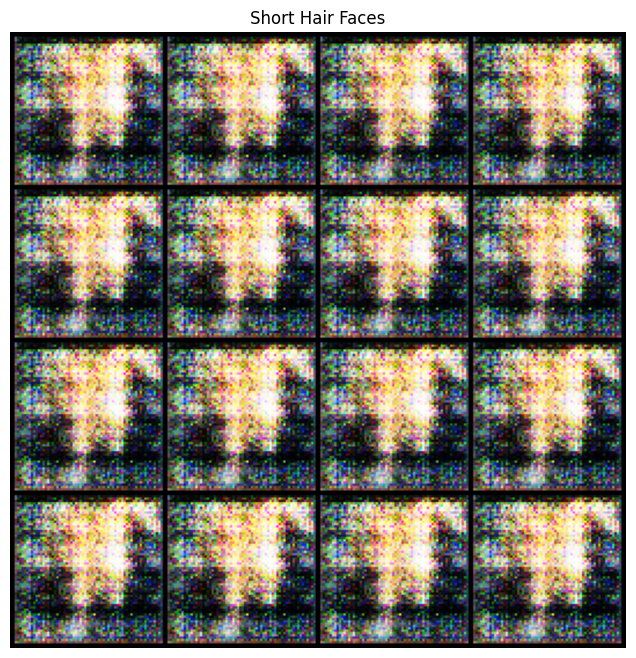

In [17]:
grid = make_grid(
    fake_short,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.transpose(
        grid.numpy(),
        (1,2,0)
    )
)

plt.title("Short Hair Faces")

plt.axis("off")

plt.show()

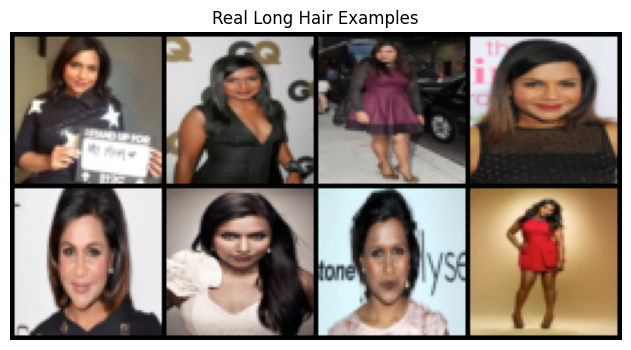

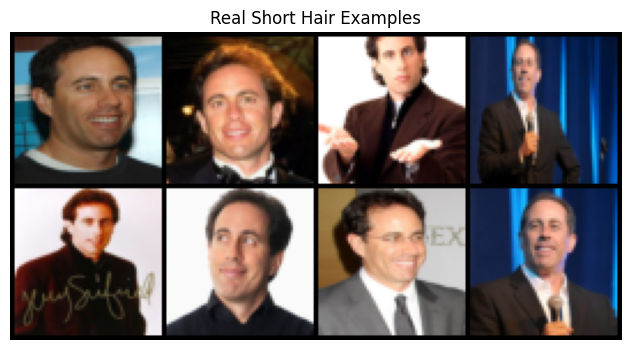

In [18]:
from torchvision.utils import make_grid

long_imgs = []
short_imgs = []

for img, label in dataset:

    if label == 1 and len(long_imgs) < 8:
        long_imgs.append(img)

    if label == 0 and len(short_imgs) < 8:
        short_imgs.append(img)

plt.figure(figsize=(8,4))
plt.imshow(
    np.transpose(
        make_grid(long_imgs, nrow=4, normalize=True).numpy(),
        (1,2,0)
    )
)
plt.title("Real Long Hair Examples")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,4))
plt.imshow(
    np.transpose(
        make_grid(short_imgs, nrow=4, normalize=True).numpy(),
        (1,2,0)
    )
)
plt.title("Real Short Hair Examples")
plt.axis("off")
plt.show()